# Phase 3 — Exchange Rate Full Comparison

**Dataset:** Exchange Rate (daily, 8 currencies vs USD)  
**Target:** SGD (Singapore Dollar)  
**Lookback:** 30 d · **Horizon:** 96 d  
**Models:** Baselines + M1 (Bahdanau) + M2 (Self-Attention LSTM) + M3 (Transformer)

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys, json, time, gc

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings("ignore")

from models import Seq2SeqBahdanau, SelfAttentionLSTM, TransformerForecaster

SEED       = 42
TARGET     = "SGD"
LOOKBACK   = 30
HORIZON    = 96
BATCH_SIZE = 32
MAX_EPOCHS = 80
LR         = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE   = 10
CLIP_GRAD  = 1.0

DATA_PATH    = "../data/multivariate-time-series-data-master/exchange_rate/exchange_rate.txt"
FIGURES_DIR  = "../outputs/figures"
RESULTS_DIR  = "../outputs/results"
CKPT_DIR     = "../outputs/checkpoints"
CONFIG_DIR   = "../outputs/configs"
LOGS_DIR     = "../outputs/logs"

for d in [FIGURES_DIR, RESULTS_DIR, CKPT_DIR, CONFIG_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}  |  Seed: {SEED}")

Device: cpu  |  Seed: 42


## 2. Load and Audit Exchange Rate

7,588 rows of daily exchange rates for 8 currencies vs USD.  
No header in file — assign standard LSTNet column names.  
Generate synthetic daily date index starting 1990-01-01.

In [2]:
COLUMN_NAMES = ["AUD", "GBP", "CAD", "CHF", "CNY", "JPY", "NZD", "SGD"]

raw = pd.read_csv(DATA_PATH, header=None, names=COLUMN_NAMES)
raw.index = pd.date_range("1990-01-01", periods=len(raw), freq="D")
raw.index.name = "Date"

print(f"Shape: {raw.shape}")
print(f"Range: {raw.index[0].date()}  \u2192  {raw.index[-1].date()}")
print(f"Columns: {list(raw.columns)}")
print(f"Missing: {raw.isnull().sum().sum()}")
print(f"\nValue ranges:")
for c in raw.columns:
    print(f"  {c:>4s}: {raw[c].min():.6f} \u2013 {raw[c].max():.6f}  (mean {raw[c].mean():.4f}, std {raw[c].std():.4f})")
raw.head(3)

Shape: (7588, 8)
Range: 1990-01-01  →  2010-10-10
Columns: ['AUD', 'GBP', 'CAD', 'CHF', 'CNY', 'JPY', 'NZD', 'SGD']
Missing: 0

Value ranges:
   AUD: 0.483297 – 1.102536  (mean 0.7770, std 0.1366)
   GBP: 1.211534 – 2.109000  (mean 1.6341, std 0.1615)
   CAD: 0.618582 – 1.091524  (mean 0.8218, std 0.1171)
   CHF: 0.548617 – 1.374079  (mean 0.8481, std 0.1689)
   CNY: 0.109292 – 0.237954  (mean 0.1428, std 0.0240)
   JPY: 0.006254 – 0.013202  (mean 0.0093, std 0.0015)
   NZD: 0.393153 – 0.882379  (mean 0.6544, std 0.1153)
   SGD: 0.523834 – 0.832556  (mean 0.6697, std 0.0828)


,AUD,GBP,CAD,CHF,CNY,JPY,NZD,SGD
Date,,,,,,,,
1990-01-01,0.7855,1.6110,0.861698,0.634196,0.211242,0.006838,0.5930,0.525486
1990-01-02,0.7818,1.6100,0.861104,0.633513,0.211242,0.006863,0.5940,0.523972
1990-01-03,0.7867,1.6293,0.861030,0.648508,0.211242,0.006975,0.5973,0.526316


## 3. Chronological Split

70 / 10 / 20 % chronological split on raw data before any scaling.

In [3]:
n = len(raw)
n_train = int(n * 0.7)
n_val   = int(n * 0.1)
n_test  = n - n_train - n_val

train_end  = raw.index[n_train - 1]
val_start  = raw.index[n_train]
val_end    = raw.index[n_train + n_val - 1]
test_start = raw.index[n_train + n_val]

print(f"Total:  {n:,}")
print(f"Train:  {n_train:,}  ({raw.index[0].date()}  \u2192  {train_end.date()})")
print(f"Val:    {n_val:,}   ({val_start.date()}  \u2192  {val_end.date()})")
print(f"Test:   {n_test:,}  ({test_start.date()}  \u2192  {raw.index[-1].date()})")

assert train_end < val_start, "LEAKAGE: train/val overlap!"
assert val_end < test_start,  "LEAKAGE: val/test overlap!"
print("\n\u2713 No split overlap.")

Total:  7,588
Train:  5,311  (1990-01-01  →  2004-07-16)
Val:    758   (2004-07-17  →  2006-08-13)
Test:   1,519  (2006-08-14  →  2010-10-10)

✓ No split overlap.


## 4. Preprocessing

1. Fit scaler on **train only** \u2192 transform all splits  
2. Append sinusoidal time features (day-of-week, month) — no hour for daily data  
3. Convert to float32, free memory

In [4]:
feature_cols = [c for c in raw.columns if c != TARGET]
all_cols     = feature_cols + [TARGET]

scaler = StandardScaler()
scaler.fit(raw.iloc[:n_train][all_cols])

scaled = pd.DataFrame(
    scaler.transform(raw[all_cols]),
    index=raw.index,
    columns=all_cols,
)

train_mean = scaled.iloc[:n_train].mean().values
train_std  = scaled.iloc[:n_train].std().values
print(f"Train mean (should be ~0): {np.round(train_mean[:5], 6)} ...")
print(f"Train std  (should be ~1): {np.round(train_std[:5], 4)} ...")

idx = scaled.index
scaled["dow_sin"]   = np.sin(2 * np.pi * idx.dayofweek / 7)
scaled["dow_cos"]   = np.cos(2 * np.pi * idx.dayofweek / 7)
scaled["month_sin"] = np.sin(2 * np.pi * idx.month / 12)
scaled["month_cos"] = np.cos(2 * np.pi * idx.month / 12)

target_idx  = scaled.columns.get_loc(TARGET)
n_features  = scaled.shape[1]
data_array  = scaled.values.astype(np.float32)

target_mean = float(scaler.mean_[all_cols.index(TARGET)])
target_std  = float(scaler.scale_[all_cols.index(TARGET)])

train_data = data_array[:n_train]
val_data   = data_array[n_train : n_train + n_val]
test_data  = data_array[n_train + n_val :]

print(f"\nFeatures: {n_features}  |  Target idx: {target_idx} ({TARGET})")
print(f"train {train_data.shape}  val {val_data.shape}  test {test_data.shape}")
print(f"dtype: {train_data.dtype}  |  Total mem: {data_array.nbytes / 1e6:.1f} MB")

del raw, scaled, data_array
gc.collect()
print("Freed raw DataFrame and full array.")

Train mean (should be ~0): [-0. -0.  0.  0.  0.] ...
Train std  (should be ~1): [1.0001 1.0001 1.0001 1.0001 1.0001] ...

Features: 12  |  Target idx: 7 (SGD)
train (5311, 12)  val (758, 12)  test (1519, 12)
dtype: float32  |  Total mem: 0.4 MB
Freed raw DataFrame and full array.


## 5. Dataset & DataLoader

In [5]:
class TimeSeriesDataset(Dataset):
    """Lazy-slicing: windows are cut on-the-fly, never pre-materialized."""

    def __init__(self, data, lookback, horizon, target_idx):
        self.data       = data
        self.lookback   = lookback
        self.horizon    = horizon
        self.target_idx = target_idx
        self.n_samples  = len(data) - lookback - horizon + 1
        assert self.n_samples > 0, (
            f"Split too short: {len(data)} rows, need >= {lookback + horizon}"
        )

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.lookback]
        y = self.data[
            idx + self.lookback : idx + self.lookback + self.horizon,
            self.target_idx,
        ]
        return torch.from_numpy(x), torch.from_numpy(y)

In [6]:
train_ds = TimeSeriesDataset(train_data, LOOKBACK, HORIZON, target_idx)
val_ds   = TimeSeriesDataset(val_data,   LOOKBACK, HORIZON, target_idx)
test_ds  = TimeSeriesDataset(test_data,  LOOKBACK, HORIZON, target_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Windows \u2014 train: {len(train_ds):,}  val: {len(val_ds):,}  test: {len(test_ds):,}")

xb, yb = next(iter(train_loader))
print(f"Batch shapes \u2014 x: {xb.shape}  y: {yb.shape}  dtype: {xb.dtype}")

Windows — train: 5,186  val: 633  test: 1,394
Batch shapes — x: torch.Size([32, 30, 12])  y: torch.Size([32, 96])  dtype: torch.float32


## 6. Baselines

Three simple baselines, all evaluated on the **test** split only:

1. **Persistence** \u2014 predict last known value for all 96 steps  
2. **Seasonal Naive 7d** \u2014 tile last 7 days of lookback window  
3. **Linear Regression** \u2014 flatten lookback window \u2192 predict all 96 steps

In [7]:
n_test_win = len(test_ds)

test_targets   = np.zeros((n_test_win, HORIZON), dtype=np.float32)
persist_preds  = np.zeros_like(test_targets)
seasonal_preds = np.zeros_like(test_targets)

for i in range(n_test_win):
    window_target = test_data[i : i + LOOKBACK, target_idx]
    test_targets[i] = test_data[i + LOOKBACK : i + LOOKBACK + HORIZON, target_idx]
    persist_preds[i]  = window_target[-1]
    seasonal_preds[i] = np.tile(window_target[-7:], HORIZON // 7 + 1)[:HORIZON]

n_train_win = len(train_ds)
X_lr = np.zeros((n_train_win, LOOKBACK * n_features), dtype=np.float32)
y_lr = np.zeros((n_train_win, HORIZON), dtype=np.float32)

for i in range(n_train_win):
    X_lr[i] = train_data[i : i + LOOKBACK].ravel()
    y_lr[i] = train_data[i + LOOKBACK : i + LOOKBACK + HORIZON, target_idx]

lr_model = LinearRegression()
lr_model.fit(X_lr, y_lr)
del X_lr, y_lr

X_lr_test = np.zeros((n_test_win, LOOKBACK * n_features), dtype=np.float32)
for i in range(n_test_win):
    X_lr_test[i] = test_data[i : i + LOOKBACK].ravel()
linear_preds = lr_model.predict(X_lr_test).astype(np.float32)
del X_lr_test, lr_model
gc.collect()

def mse_mae(preds, targets):
    return float(np.mean((preds - targets) ** 2)), float(np.mean(np.abs(preds - targets)))

def to_original(arr):
    return arr * target_std + target_mean

baselines = {}
for name, preds in [("Persistence", persist_preds),
                     ("Seasonal Naive 7d", seasonal_preds),
                     ("Linear Regression", linear_preds)]:
    s_mse, s_mae = mse_mae(preds, test_targets)
    o_mse, o_mae = mse_mae(to_original(preds), to_original(test_targets))
    baselines[name] = {"MSE_scaled": round(s_mse, 6), "MAE_scaled": round(s_mae, 6),
                       "MSE_original": round(o_mse, 4), "MAE_original": round(o_mae, 4)}

baseline_df = pd.DataFrame(baselines).T
baseline_df.index.name = "Model"
print(baseline_df.to_string())

baseline_df.to_csv(os.path.join(RESULTS_DIR, "exchange_96_baselines.csv"))
print(f"\n\u2713 Saved \u2192 {RESULTS_DIR}/exchange_96_baselines.csv")

                   MSE_scaled  MAE_scaled  MSE_original  MAE_original
Model                                                                
Persistence          0.068038    0.197800        0.0002        0.0110
Seasonal Naive 7d    0.072133    0.205866        0.0002        0.0115
Linear Regression    0.098691    0.240094        0.0003        0.0134

✓ Saved → ../outputs/results/exchange_96_baselines.csv


## 7. Shared Training Infrastructure

`train_and_evaluate()` handles the full training loop, validation with early stopping,
test evaluation, and saves all artifacts (checkpoint, config JSON, training log CSV, results CSV).

In [8]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_and_evaluate(model, model_name, train_ldr, val_ldr, test_ldr,
                       criterion, device, config,
                       tf_start=None, tf_end=None, tf_anneal=None,
                       warmup_epochs=0):
    """Train a model with early stopping, evaluate on test, save all artifacts."""
    target_lr = config["lr"]
    optimizer = torch.optim.Adam(model.parameters(), lr=target_lr,
                                  weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=4, factor=0.5)

    use_tf = tf_start is not None
    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_epoch = 0
    wait = 0

    ckpt_path = os.path.join(CKPT_DIR, f"exchange_96_{model_name}.pt")
    t0 = time.time()

    for epoch in range(1, config["max_epochs"] + 1):
        if warmup_epochs and epoch <= warmup_epochs:
            warmup_lr = target_lr * epoch / warmup_epochs
            for pg in optimizer.param_groups:
                pg["lr"] = warmup_lr

        tf_ratio = 0.0
        if use_tf:
            tf_ratio = max(tf_end, tf_start - (tf_start - tf_end) * epoch / tf_anneal)

        model.train()
        epoch_loss = 0.0
        for xb, yb in train_ldr:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb, targets=yb, tf_ratio=tf_ratio) if use_tf else model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config["clip_grad"])
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        train_losses.append(epoch_loss / len(train_ldr.dataset))

        model.eval()
        vloss = 0.0
        with torch.no_grad():
            for xb, yb in val_ldr:
                xb, yb = xb.to(device), yb.to(device)
                vloss += criterion(model(xb), yb).item() * xb.size(0)
        val_losses.append(vloss / len(val_ldr.dataset))

        if not (warmup_epochs and epoch <= warmup_epochs):
            scheduler.step(val_losses[-1])

        tag = ""
        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            best_epoch = epoch
            wait = 0
            torch.save(model.state_dict(), ckpt_path)
            tag = " \u2713"
        else:
            wait += 1

        cur_lr = optimizer.param_groups[0]["lr"]
        tf_str = f" | TF {tf_ratio:.2f}" if use_tf else ""
        if epoch == 1 or epoch % 5 == 0 or tag or wait >= config["patience"]:
            print(f"Ep {epoch:3d}/{config['max_epochs']} | "
                  f"Train {train_losses[-1]:.6f} | Val {val_losses[-1]:.6f} | "
                  f"Best {best_val_loss:.6f} (ep {best_epoch})"
                  f"{tf_str} | LR {cur_lr:.1e} | {time.time()-t0:.0f}s{tag}")

        if wait >= config["patience"]:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

    elapsed = time.time() - t0
    n_epochs = len(train_losses)
    print(f"\nDone in {elapsed:.1f}s ({n_epochs} epochs). "
          f"Best val MSE: {best_val_loss:.6f} @ epoch {best_epoch}")

    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))

    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in test_ldr:
            xb = xb.to(device)
            all_preds.append(model(xb).cpu().numpy())
            all_targets.append(yb.numpy())

    all_preds   = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    s_mse, s_mae = mse_mae(all_preds, all_targets)
    o_mse, o_mae = mse_mae(to_original(all_preds), to_original(all_targets))

    results = {
        "MSE_scaled": round(s_mse, 6), "MAE_scaled": round(s_mae, 6),
        "MSE_original": round(o_mse, 4), "MAE_original": round(o_mae, 4),
    }

    res_df = pd.DataFrame([results], index=[model_name])
    res_df.index.name = "Model"
    res_df.to_csv(os.path.join(RESULTS_DIR, f"exchange_96_{model_name}.csv"))

    run_config = {
        "dataset": "Exchange Rate", "target": TARGET, "lookback": LOOKBACK,
        "horizon": HORIZON, "batch_size": BATCH_SIZE, "model": model_name,
        "total_params": count_parameters(model),
        "best_epoch": best_epoch, "best_val_mse": round(best_val_loss, 6),
        "training_time_s": round(elapsed, 1),
    }
    run_config.update(config)
    if use_tf:
        run_config.update(tf_start=tf_start, tf_end=tf_end, tf_anneal=tf_anneal)
    if warmup_epochs:
        run_config["warmup_epochs"] = warmup_epochs
    with open(os.path.join(CONFIG_DIR, f"exchange_96_{model_name}.json"), "w") as f:
        json.dump(run_config, f, indent=2)

    log_df = pd.DataFrame({"epoch": range(1, n_epochs + 1),
                            "train_mse": train_losses, "val_mse": val_losses})
    log_df.to_csv(os.path.join(LOGS_DIR, f"exchange_96_{model_name}_log.csv"), index=False)

    print(f"\u2713 Checkpoint, config, log, and results saved for {model_name}.")
    return results, {"train_mse": train_losses, "val_mse": val_losses}, all_preds

## 8. Train + Eval M1 — Bahdanau Attention

LSTM encoder-decoder with additive (Bahdanau) attention.  
Autoregressive decoder with teacher forcing (scheduled sampling 1.0 → 0.0 over 30 epochs).  
**Dropout=0.3** based on Phase 1 finding (0.2 caused immediate overfitting on ETTh1).

In [9]:
torch.manual_seed(SEED)
np.random.seed(SEED)

m1 = Seq2SeqBahdanau(
    n_features=n_features,
    hidden_dim=64,
    enc_layers=2,
    horizon=HORIZON,
    target_idx=target_idx,
    dropout=0.3,
).to(DEVICE)

print(f"M1 (Bahdanau) parameters: {count_parameters(m1):,}")
print(m1, "\n")

m1_config = dict(lr=LR, weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                 clip_grad=CLIP_GRAD, max_epochs=MAX_EPOCHS,
                 hidden_dim=64, enc_layers=2, dropout=0.3)

m1_results, m1_log, m1_preds = train_and_evaluate(
    m1, "bahdanau", train_loader, val_loader, test_loader,
    nn.MSELoss(), DEVICE, m1_config,
    tf_start=1.0, tf_end=0.0, tf_anneal=30,
)

print(f"\nM1 Test Results: {m1_results}")
del m1; gc.collect()

M1 (Bahdanau) parameters: 95,105
Seq2SeqBahdanau(
  (encoder): LSTM(12, 64, num_layers=2, batch_first=True, dropout=0.3)
  (attention): BahdanauAttention(
    (W_enc): Linear(in_features=64, out_features=64, bias=False)
    (W_dec): Linear(in_features=64, out_features=64, bias=False)
    (v): Linear(in_features=64, out_features=1, bias=False)
  )
  (decoder_cell): LSTMCell(65, 64)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
) 

Ep   1/80 | Train 0.112921 | Val 0.948571 | Best 0.948571 (ep 1) | TF 0.97 | LR 1.0e-03 | 20s ✓
Ep   5/80 | Train 0.011263 | Val 2.286943 | Best 0.948571 (ep 1) | TF 0.83 | LR 1.0e-03 | 89s
Ep  10/80 | Train 0.011460 | Val 1.774057 | Best 0.948571 (ep 1) | TF 0.67 | LR 5.0e-04 | 175s
Ep  11/80 | Train 0.011565 | Val 1.373940 | Best 0.948571 (ep 1) | TF 0.63 | LR 2.5e-04 | 191s

Early stopping at epoch 11.

Done in 191.4s (11 epochs). Best val MSE: 0.948571 @ epoch 1
✓ Checkpoint, config, log, and resul

41

## 9. Train + Eval M2 — Self-Attention LSTM

LSTM encoder with scaled dot-product self-attention applied over encoder states,
then autoregressive LSTM decoder with Bahdanau attention over the self-attended states.  
Same teacher forcing schedule as M1. LR=5e-4, dropout=0.2.

In [10]:
torch.manual_seed(SEED)
np.random.seed(SEED)

m2 = SelfAttentionLSTM(
    n_features=n_features,
    hidden_dim=60,
    enc_layers=2,
    horizon=HORIZON,
    target_idx=target_idx,
    dropout=0.2,
).to(DEVICE)

print(f"M2 (Self-Attention LSTM) parameters: {count_parameters(m2):,}")
print(m2, "\n")

m2_config = dict(lr=5e-4, weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                 clip_grad=CLIP_GRAD, max_epochs=MAX_EPOCHS,
                 hidden_dim=60, enc_layers=2, dropout=0.2)

m2_results, m2_log, m2_preds = train_and_evaluate(
    m2, "selfattn", train_loader, val_loader, test_loader,
    nn.MSELoss(), DEVICE, m2_config,
    tf_start=1.0, tf_end=0.0, tf_anneal=30,
)

print(f"\nM2 Test Results: {m2_results}")
del m2; gc.collect()

M2 (Self-Attention LSTM) parameters: 94,681
SelfAttentionLSTM(
  (encoder): LSTM(12, 60, num_layers=2, batch_first=True, dropout=0.2)
  (W_q): Linear(in_features=60, out_features=60, bias=False)
  (W_k): Linear(in_features=60, out_features=60, bias=False)
  (W_v): Linear(in_features=60, out_features=60, bias=False)
  (attention): BahdanauAttention(
    (W_enc): Linear(in_features=60, out_features=60, bias=False)
    (W_dec): Linear(in_features=60, out_features=60, bias=False)
    (v): Linear(in_features=60, out_features=1, bias=False)
  )
  (decoder_cell): LSTMCell(61, 60)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc_out): Linear(in_features=60, out_features=1, bias=True)
) 

Ep   1/80 | Train 0.176961 | Val 1.700480 | Best 1.700480 (ep 1) | TF 0.97 | LR 5.0e-04 | 16s ✓
Ep   2/80 | Train 0.015128 | Val 1.106188 | Best 1.106188 (ep 2) | TF 0.93 | LR 5.0e-04 | 32s ✓
Ep   5/80 | Train 0.009321 | Val 1.681639 | Best 1.106188 (ep 2) | TF 0.83 | LR 5.0e-04 | 80s
Ep   6/80 | Train 0.00905

41

## 10. Train + Eval M3 — Transformer Encoder-Decoder

Full Transformer with encoder (multi-head self-attention) + decoder (masked self-attention
+ cross-attention) using 96 learned query tokens for parallel decode.  
LR=5e-4 with 5-epoch warmup, dropout=0.2. No teacher forcing.

In [11]:
torch.manual_seed(SEED)
np.random.seed(SEED)

m3 = TransformerForecaster(
    n_features=n_features,
    d_model=64,
    n_heads=4,
    n_layers=1,
    dim_ff=144,
    horizon=HORIZON,
    dropout=0.2,
).to(DEVICE)

print(f"M3 (Transformer) parameters: {count_parameters(m3):,}")
print(m3, "\n")

m3_config = dict(lr=5e-4, weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                 clip_grad=CLIP_GRAD, max_epochs=MAX_EPOCHS,
                 d_model=64, n_heads=4, n_layers=1, dim_ff=144, dropout=0.2)

m3_results, m3_log, m3_preds = train_and_evaluate(
    m3, "transformer", train_loader, val_loader, test_loader,
    nn.MSELoss(), DEVICE, m3_config,
    warmup_epochs=5,
)

print(f"\nM3 Test Results: {m3_results}")
del m3; gc.collect()

M3 (Transformer) parameters: 94,881
TransformerForecaster(
  (input_proj): Linear(in_features=12, out_features=64, bias=True)
  (pos_enc): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=144, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=144, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (transformer_decoder): TransformerDecoder(
    (layers): ModuleList(
      (0): TransformerDecoderLayer(
        (self_attn): Multihe

107

## 11. Comparison Table

Unified table with all baselines + M1 + M2 + M3.

In [12]:
model_results = {
    "LSTM+Bahdanau (M1)": m1_results,
    "LSTM+SelfAttn (M2)": m2_results,
    "Transformer (M3)": m3_results,
}

model_df = pd.DataFrame(model_results).T
model_df.index.name = "Model"

comparison_df = pd.concat([baseline_df, model_df])

print("=" * 78)
print(f"  Exchange Rate  |  Lookback={LOOKBACK}  |  Horizon={HORIZON}  |  Test Set")
print("=" * 78)
print(comparison_df.to_string())
print("=" * 78)

comparison_df.to_csv(os.path.join(RESULTS_DIR, "exchange_96_comparison.csv"))
print(f"\n\u2713 Saved \u2192 {RESULTS_DIR}/exchange_96_comparison.csv")

  Exchange Rate  |  Lookback=30  |  Horizon=96  |  Test Set
                    MSE_scaled  MAE_scaled  MSE_original  MAE_original
Model                                                                 
Persistence           0.068038    0.197800        0.0002        0.0110
Seasonal Naive 7d     0.072133    0.205866        0.0002        0.0115
Linear Regression     0.098691    0.240094        0.0003        0.0134
LSTM+Bahdanau (M1)    0.544539    0.612958        0.0017        0.0341
LSTM+SelfAttn (M2)    0.630489    0.662510        0.0020        0.0369
Transformer (M3)      0.683166    0.718454        0.0021        0.0400

✓ Saved → ../outputs/results/exchange_96_comparison.csv


## 12. Comparison Figures

Publication-quality figures for Exchange Rate h=96 comparison:

1. **MSE/MAE bar chart** — all models side by side  
2. **Overlaid loss curves** — training dynamics for M1, M2, M3  
3. **Forecast overlay** — one test sample with all model predictions

✓ Saved comparison bar chart


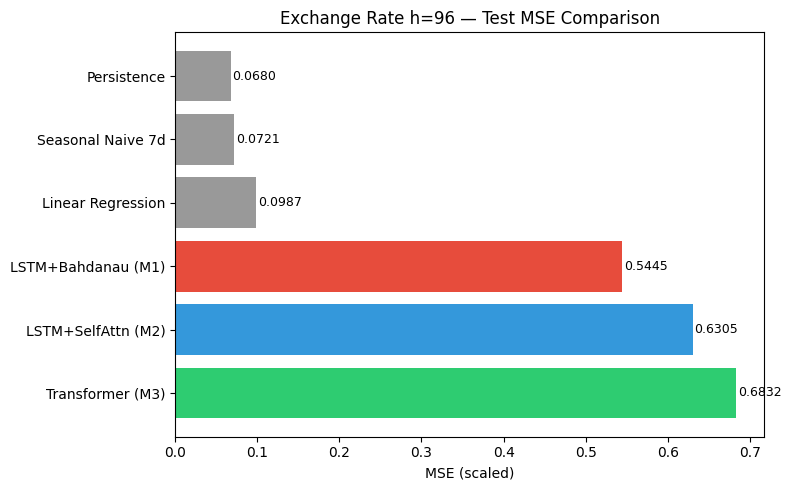

✓ Saved loss curves


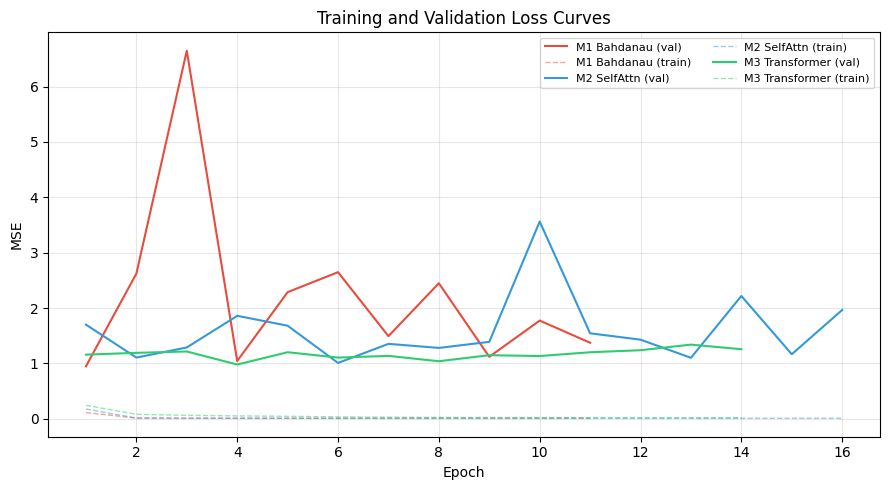

✓ Saved forecast overlay


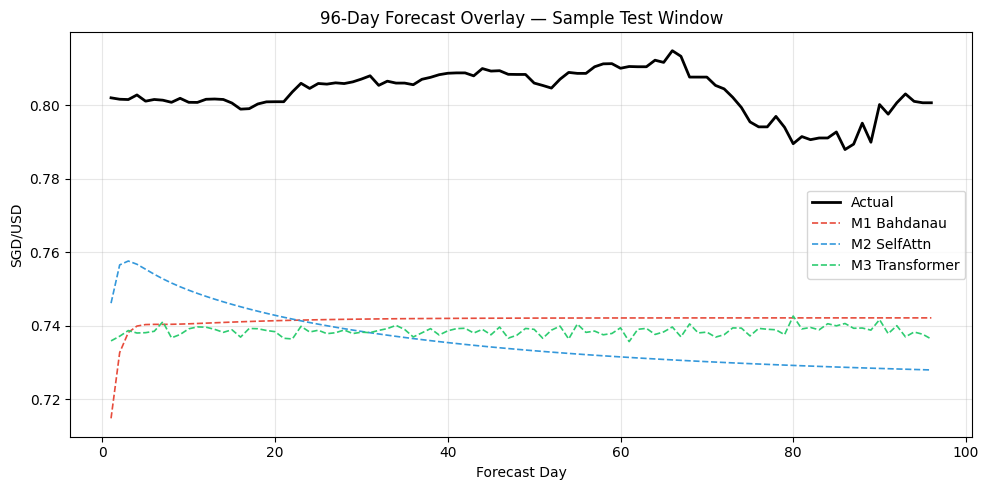


✓ All figures saved to ../outputs/figures


In [13]:
MODEL_COLORS = {"M1 Bahdanau": "#e74c3c", "M2 SelfAttn": "#3498db",
                "M3 Transformer": "#2ecc71"}

# \u2500\u2500 Figure 1: MSE bar chart \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
fig, ax = plt.subplots(figsize=(8, 5))
names = comparison_df.index.tolist()
mses  = comparison_df["MSE_scaled"].values
colors = ["#999999"] * len(baselines) + list(MODEL_COLORS.values())
ax.barh(names, mses, color=colors)
ax.set_xlabel("MSE (scaled)")
ax.set_title("Exchange Rate h=96 \u2014 Test MSE Comparison")
ax.invert_yaxis()
for i, v in enumerate(mses):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "exchange_96_comparison_bar.png"),
            dpi=150, bbox_inches="tight")
print("\u2713 Saved comparison bar chart")
plt.show()

# \u2500\u2500 Figure 2: Overlaid loss curves \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
fig, ax = plt.subplots(figsize=(9, 5))
for (label, color), log in zip(MODEL_COLORS.items(),
                                [m1_log, m2_log, m3_log]):
    epochs = range(1, len(log["val_mse"]) + 1)
    ax.plot(epochs, log["val_mse"], color=color, linewidth=1.5,
            label=f"{label} (val)")
    ax.plot(epochs, log["train_mse"], color=color, linewidth=1,
            linestyle="--", alpha=0.5, label=f"{label} (train)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Training and Validation Loss Curves")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "exchange_96_loss_curves.png"),
            dpi=150, bbox_inches="tight")
print("\u2713 Saved loss curves")
plt.show()

# \u2500\u2500 Figure 3: Forecast overlay \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
fig, ax = plt.subplots(figsize=(10, 5))
sample_idx = 100
true_vals  = to_original(test_targets[sample_idx])
days = range(1, HORIZON + 1)
ax.plot(days, true_vals, "k-", label="Actual", linewidth=2)
for (label, color), preds_arr in zip(MODEL_COLORS.items(),
                                      [m1_preds, m2_preds, m3_preds]):
    ax.plot(days, to_original(preds_arr[sample_idx]), "--",
            label=label, color=color, linewidth=1.2)
ax.set_xlabel("Forecast Day")
ax.set_ylabel("SGD/USD")
ax.set_title("96-Day Forecast Overlay \u2014 Sample Test Window")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "exchange_96_forecast_overlay.png"),
            dpi=150, bbox_inches="tight")
print("\u2713 Saved forecast overlay")
plt.show()

print(f"\n\u2713 All figures saved to {FIGURES_DIR}")